# Partie I — MLP sur données tabulaires StatsBomb

**Projet Deep Learning EMSI — FootAI**  
Notebook autonome consacré aux données tabulaires et à l'ingénierie PyTorch.

## Objectif de la partie

Construire un dataset tabulaire réel à partir de **StatsBomb Open Data** et entraîner un **MLP** pour prédire le niveau de danger d'un tir.

La cible est construite à partir du `xG` StatsBomb :

- `0` : danger faible ;
- `1` : danger moyen ;
- `2` : danger élevé.

Le `xG` n'est pas utilisé comme variable d'entrée afin d'éviter une fuite d'information.

## Plan du notebook

1. Installation, imports et fonctions communes.
2. Chargement StatsBomb.
3. Préparation du dataset tabulaire.
4. MLP avec `nn.Sequential`.
5. MLP avec classe personnalisée.
6. Comparaison des initialisations : gaussienne, constante, Xavier.
7. Sauvegarde/rechargement du meilleur modèle.
8. Évaluation : accuracy, precision, recall, F1-score, matrice de confusion.
9. Analyse critique et synthèse.


## Rappels théoriques essentiels

- `nn.Module` est la classe de base de tous les modèles PyTorch.
- `forward()` définit la propagation avant.
- Les paramètres entraînables sont accessibles avec `named_parameters()`.
- `state_dict()` contient les poids et biais sauvegardables du modèle.
- Le gradient est calculé par rétropropagation avec `loss.backward()`.
- Le `device` permet d'exécuter le modèle sur CPU ou GPU.
- Une bonne préparation tabulaire nécessite : nettoyage, encodage, normalisation et séparation train/validation/test.


In [ ]:
# ============================================================
# 0. Installation minimale
# ============================================================

import sys, subprocess, importlib.util

def pip_install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Colab possède déjà torch/torchvision dans la majorité des cas.
required = {
    "requests": "requests",
    "yaml": "pyyaml",
    "sklearn": "scikit-learn",
    "PIL": "pillow",
    "tqdm": "tqdm",
    "roboflow": "roboflow",
}

for import_name, package_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        pip_install(package_name)

print("Installations vérifiées.")


Installations vérifiées.


In [ ]:
# ============================================================
# 0. Imports et configuration générale
# ============================================================

import os
import re
import math
import json
import random
import shutil
import zipfile
import requests
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms, datasets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/content/FootAI_Partie1_MLP")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR = OUTPUT_DIR / "figures"

for p in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", DEVICE)


Device utilisé : cuda


In [ ]:
# ============================================================
# 0. Fonctions communes
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


def compute_classification_metrics(y_true, y_pred, labels=None):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def plot_confusion_matrix_simple(y_true, y_pred, class_names, title="Matrice de confusion", save_name=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Vraie classe")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()


def plot_training_curves(history, title="Courbes d'entraînement", save_name=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history.get("train_loss", []), label="train loss")
    ax.plot(history.get("val_loss", []), label="val loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()

    if "train_acc" in history and "val_acc" in history:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(history["train_acc"], label="train accuracy")
        ax.plot(history["val_acc"], label="val accuracy")
        ax.set_title(title + " - Accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        if save_name:
            fig.savefig(FIG_DIR / ("acc_" + save_name), dpi=150, bbox_inches="tight")
        plt.show()


def save_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)


def load_checkpoint(model, path, device=DEVICE):
    model.load_state_dict(torch.load(path, map_location=device))
    return model


def train_classifier(model, train_loader, val_loader, epochs=8, lr=1e-3, device=DEVICE, clip_norm=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_f1 = -1

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_true, train_pred = [], [], []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.step()

            train_losses.append(loss.item())
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            train_pred.extend(preds)
            train_true.extend(yb.detach().cpu().numpy())

        val_loss, val_metrics, _, _ = evaluate_classifier(model, val_loader, device=device, return_preds=True)
        train_metrics = compute_classification_metrics(train_true, train_pred)

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={history['train_loss'][-1]:.4f} | val_loss={val_loss:.4f} | val_f1={val_metrics['f1']:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_state


@torch.no_grad()
def evaluate_classifier(model, loader, device=DEVICE, return_preds=False):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    losses, y_true, y_pred = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        losses.append(loss.item())
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.cpu().numpy())

    metrics = compute_classification_metrics(y_true, y_pred)
    mean_loss = float(np.mean(losses)) if losses else 0.0

    if return_preds:
        return mean_loss, metrics, np.array(y_true), np.array(y_pred)
    return mean_loss, metrics


## Vérification rapide

Cette cellule confirme que le notebook utilise le bon dossier de travail et le bon device.


In [ ]:

print("Projet :", PROJECT_DIR)
print("Dossier outputs :", OUTPUT_DIR)
print("Device :", DEVICE)


Projet : /content/FootAI_Partie1_MLP
Dossier outputs : /content/FootAI_Partie1_MLP/outputs
Device : cuda


# Partie I — MLP sur données tabulaires StatsBomb

## Objectif

On utilise les événements **StatsBomb Open Data** pour construire un dataset tabulaire de tirs.

**Tâche :** prédire le niveau de danger d'un tir :

- `0` : danger faible ;
- `1` : danger moyen ;
- `2` : danger élevé.

La cible est construite à partir du `xG` StatsBomb, mais le `xG` n'est **pas utilisé comme variable d'entrée**, pour éviter la fuite d'information.


In [ ]:
# ============================================================
# 1. Chargement StatsBomb Open Data sans authentification
# ============================================================

STATS_BOMB_BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"


def fetch_json(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()


def choose_available_competition():
    # Choisit automatiquement une compétition disponible dans l'open data.
    competitions = fetch_json(f"{STATS_BOMB_BASE}/competitions.json")
    comp_df = pd.DataFrame(competitions)

    # Quelques compétitions StatsBomb connues. Si l'une échoue, on cherche une autre compétition.
    preferred = [
        (43, 106),  # Coupe du monde 2022 si disponible
        (43, 3),    # Coupe du monde 2018
        (72, 30),   # Women's World Cup 2019
        (11, 90),
        (16, 4),
    ]

    available_pairs = set(zip(comp_df["competition_id"], comp_df["season_id"]))
    for pair in preferred:
        if pair in available_pairs:
            return pair

    first = comp_df.iloc[0]
    return int(first["competition_id"]), int(first["season_id"])


def load_statsbomb_events(max_matches=12):
    competition_id, season_id = choose_available_competition()
    print(f"Compétition choisie : competition_id={competition_id}, season_id={season_id}")

    matches_url = f"{STATS_BOMB_BASE}/matches/{competition_id}/{season_id}.json"
    matches = fetch_json(matches_url)
    matches_df = pd.DataFrame(matches)
    matches_df = matches_df.head(max_matches).copy()
    print("Nombre de matchs chargés :", len(matches_df))

    all_events = []
    for match_id in tqdm(matches_df["match_id"], desc="Chargement événements"):
        events_url = f"{STATS_BOMB_BASE}/events/{match_id}.json"
        raw_events = fetch_json(events_url)
        df = pd.json_normalize(raw_events, sep="_")
        df["match_id"] = match_id
        all_events.append(df)

    events_df = pd.concat(all_events, ignore_index=True)
    print("Nombre total d'événements :", len(events_df))
    return events_df, matches_df


events_df_all, matches_df = load_statsbomb_events(max_matches=12)
events_df_all.head()

Compétition choisie : competition_id=43, season_id=106
Nombre de matchs chargés : 12


Chargement événements:   0%|          | 0/12 [00:00<?, ?it/s]

Nombre total d'événements : 43613


,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,...,ball_recovery_offensive,pass_straight,pass_no_touch,shot_redirect,goalkeeper_punched_out,bad_behaviour_card_id,bad_behaviour_card_name,block_save_block,shot_saved_off_target,goalkeeper_shot_saved_off_target
0,1f60fe1e-0340-49e2-975e-f16f54c5da1a,1,1,00:00:00.000,0,0,1,0.00000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,d5ffdab0-a19a-497e-a0f6-d5403bfcc2b5,2,1,00:00:00.000,0,0,1,0.00000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c6dcab53-5a07-4a6e-ab8b-64e9f9133d19,3,1,00:00:00.000,0,0,1,0.00000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,396c6ebb-5ba7-415c-ba37-88ff51f7c737,4,1,00:00:00.000,0,0,1,0.00000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05a57281-9295-408a-9c4f-e32d7fad4d96,5,1,00:00:00.460,0,0,2,0.83469,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# 1. Préparation des tirs StatsBomb pour le MLP
# ============================================================

def extract_xy(location):
    if isinstance(location, list) and len(location) >= 2:
        return float(location[0]), float(location[1])
    return np.nan, np.nan


def compute_distance_angle_to_goal(x, y):
    # StatsBomb pitch: longueur 120, largeur 80. But adverse centré en (120, 40).
    goal_x, goal_y = 120.0, 40.0
    left_post_y, right_post_y = 36.0, 44.0

    distance = math.sqrt((goal_x - x) ** 2 + (goal_y - y) ** 2)

    # angle entre les deux poteaux depuis la position du tireur
    a = math.sqrt((goal_x - x) ** 2 + (left_post_y - y) ** 2)
    b = math.sqrt((goal_x - x) ** 2 + (right_post_y - y) ** 2)
    c = 8.0
    denom = max(2 * a * b, 1e-8)
    cos_angle = np.clip((a*a + b*b - c*c) / denom, -1, 1)
    angle = math.acos(cos_angle)
    return distance, angle


def build_shot_dataset(events_df):
    shots = events_df[events_df["type_name"] == "Shot"].copy()
    shots = shots.dropna(subset=["shot_statsbomb_xg", "location"]).copy()

    xy = shots["location"].apply(extract_xy)
    shots["location_x"] = xy.apply(lambda v: v[0])
    shots["location_y"] = xy.apply(lambda v: v[1])

    dist_angle = shots.apply(lambda r: compute_distance_angle_to_goal(r["location_x"], r["location_y"]), axis=1)
    shots["distance_to_goal"] = dist_angle.apply(lambda v: v[0])
    shots["angle_to_goal"] = dist_angle.apply(lambda v: v[1])

    shots["under_pressure"] = shots.get("under_pressure", False).fillna(False).astype(int)
    shots["minute"] = shots["minute"].fillna(0).astype(float)

    # Cible : danger faible/moyen/élevé selon les quantiles du xG.
    shots["target"] = pd.qcut(shots["shot_statsbomb_xg"], q=3, labels=False, duplicates="drop")
    shots = shots.dropna(subset=["target"]).copy()
    shots["target"] = shots["target"].astype(int)

    numeric_cols = ["location_x", "location_y", "distance_to_goal", "angle_to_goal", "minute", "under_pressure"]
    categorical_cols = [
        "shot_body_part_name",
        "shot_technique_name",
        "shot_type_name",
        "play_pattern_name",
    ]
    for col in categorical_cols:
        if col not in shots.columns:
            shots[col] = "Unknown"
        shots[col] = shots[col].fillna("Unknown").astype(str)

    X_num = shots[numeric_cols].fillna(0)
    X_cat = pd.get_dummies(shots[categorical_cols], drop_first=False)
    X = pd.concat([X_num, X_cat], axis=1)
    y = shots["target"].values

    return shots, X, y


shots_df, X_df, y = build_shot_dataset(events_df_all)
print("Nombre de tirs :", len(shots_df))
print("Nombre de variables :", X_df.shape[1])
print("Distribution cible :")
print(pd.Series(y).value_counts().sort_index())
X_df.head()

Nombre de tirs : 228
Nombre de variables : 29
Distribution cible :
0    76
1    76
2    76
Name: count, dtype: int64


,location_x,location_y,distance_to_goal,angle_to_goal,minute,under_pressure,shot_body_part_name_Head,shot_body_part_name_Left Foot,shot_body_part_name_Other,shot_body_part_name_Right Foot,...,shot_type_name_Penalty,play_pattern_name_From Corner,play_pattern_name_From Counter,play_pattern_name_From Free Kick,play_pattern_name_From Goal Kick,play_pattern_name_From Keeper,play_pattern_name_From Kick Off,play_pattern_name_From Throw In,play_pattern_name_Other,play_pattern_name_Regular Play
99,96.5,40.7,23.510423,0.336909,2.0,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
202,83.9,45.0,36.444616,0.216633,3.0,0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
297,86.8,38.4,33.238532,0.239265,8.0,0,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
305,107.0,48.3,15.423683,0.438296,9.0,0,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
481,113.3,34.9,8.420214,0.773417,14.0,0,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
# ============================================================
# 1. Split train / validation / test + normalisation
# ============================================================

X_values = X_df.values.astype(np.float32)
y_values = y.astype(np.int64)

indices = np.arange(len(X_values))
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.20, random_state=42, stratify=y_values
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.20, random_state=42, stratify=y_values[train_val_idx]
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_values[train_idx])
X_val = scaler.transform(X_values[val_idx])
X_test = scaler.transform(X_values[test_idx])

y_train = y_values[train_idx]
y_val = y_values[val_idx]
y_test = y_values[test_idx]

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader_tab = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader_tab = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader_tab = DataLoader(test_ds, batch_size=64, shuffle=False)

n_features = X_train.shape[1]
n_classes_tab = len(np.unique(y_values))
print("n_features=", n_features, "n_classes=", n_classes_tab)

n_features= 29 n_classes= 3


In [ ]:
# ============================================================
# 1. MLP version nn.Sequential et MLP version classe personnalisée
# ============================================================

class MLPCustom(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.15):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)


def make_mlp_sequential(input_dim, hidden_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.15),
        nn.Linear(hidden_dim, hidden_dim // 2),
        nn.ReLU(),
        nn.Dropout(0.15),
        nn.Linear(hidden_dim // 2, output_dim),
    )


def initialize_model(model, strategy="xavier"):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            if strategy == "gaussian":
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
            elif strategy == "constant":
                nn.init.constant_(module.weight, 0.01)
            elif strategy == "xavier":
                nn.init.xavier_uniform_(module.weight)
            else:
                raise ValueError("Stratégie inconnue")
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    return model


# Inspection demandée : named_parameters et state_dict
model_demo = MLPCustom(n_features, 64, n_classes_tab)
print("Paramètres du modèle personnalisé :")
for name, param in model_demo.named_parameters():
    print(name, tuple(param.shape), "requires_grad=", param.requires_grad)

print("\nClés du state_dict :")
print(list(model_demo.state_dict().keys())[:10])

Paramètres du modèle personnalisé :
fc1.weight (64, 29) requires_grad= True
fc1.bias (64,) requires_grad= True
fc2.weight (32, 64) requires_grad= True
fc2.bias (32,) requires_grad= True
fc3.weight (3, 32) requires_grad= True
fc3.bias (3,) requires_grad= True

Clés du state_dict :
['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']


Epoch 01/8 | train_loss=1.2626 | val_loss=1.0336 | val_f1=0.4252
Epoch 02/8 | train_loss=1.1405 | val_loss=0.9967 | val_f1=0.4599
Epoch 03/8 | train_loss=1.0251 | val_loss=0.9673 | val_f1=0.5413
Epoch 04/8 | train_loss=0.9344 | val_loss=0.9466 | val_f1=0.5119
Epoch 05/8 | train_loss=0.9524 | val_loss=0.9283 | val_f1=0.4829
Epoch 06/8 | train_loss=0.8923 | val_loss=0.9110 | val_f1=0.5119
Epoch 07/8 | train_loss=0.9096 | val_loss=0.8958 | val_f1=0.5393
Epoch 08/8 | train_loss=0.7979 | val_loss=0.8781 | val_f1=0.5653
Résultats MLP nn.Sequential : {'test_loss': 0.8970949649810791, 'accuracy': 0.6956521739130435, 'precision': 0.7030995006698331, 'recall': 0.6956521739130435, 'f1': 0.6980249794457611}


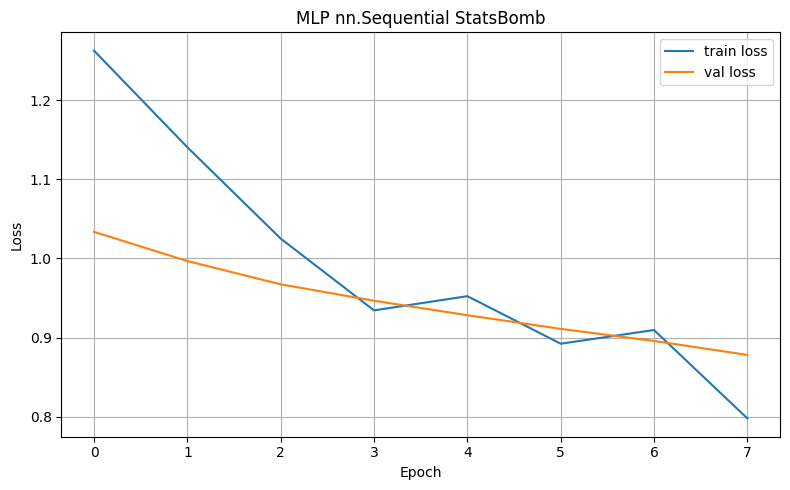

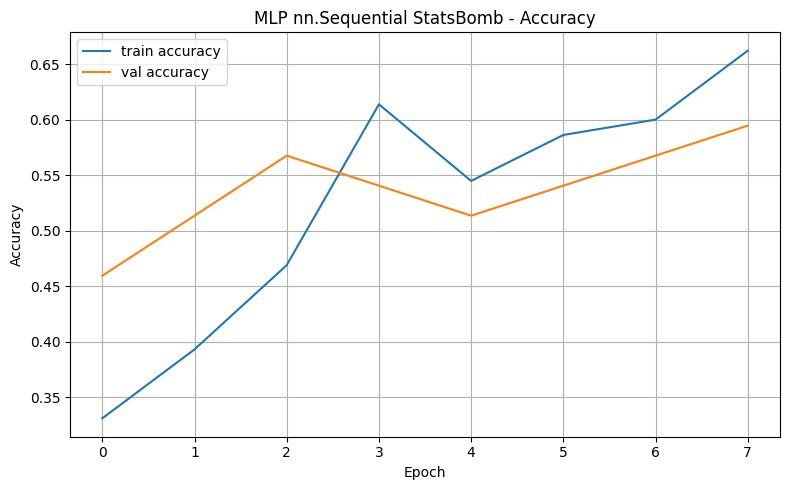

In [ ]:
# ============================================================
# 1. Entraînement rapide du MLP nn.Sequential demandé par le cahier des charges
# ============================================================

mlp_seq = make_mlp_sequential(n_features, 64, n_classes_tab)
mlp_seq = initialize_model(mlp_seq, "xavier")

seq_history, seq_best_state = train_classifier(
    mlp_seq,
    train_loader_tab,
    val_loader_tab,
    epochs=8,
    lr=1e-3,
    device=DEVICE,
)

if seq_best_state is not None:
    mlp_seq.load_state_dict(seq_best_state)

seq_test_loss, seq_test_metrics, seq_y_true, seq_y_pred = evaluate_classifier(
    mlp_seq,
    test_loader_tab,
    device=DEVICE,
    return_preds=True,
)

print("Résultats MLP nn.Sequential :", {"test_loss": seq_test_loss, **seq_test_metrics})
plot_training_curves(seq_history, "MLP nn.Sequential StatsBomb", "mlp_sequential_training_curves.png")

In [ ]:
# ============================================================
# 1. Expérience : comparaison des initialisations
# ============================================================

mlp_results = []
mlp_histories = {}

for strategy in ["gaussian", "constant", "xavier"]:
    print("\n" + "="*70)
    print("Initialisation :", strategy)

    model = MLPCustom(n_features, 64, n_classes_tab)
    model = initialize_model(model, strategy)

    history, best_state = train_classifier(
        model, train_loader_tab, val_loader_tab, epochs=10, lr=1e-3, device=DEVICE
    )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_metrics, y_true, y_pred = evaluate_classifier(
        model, test_loader_tab, device=DEVICE, return_preds=True
    )

    row = {"model": "MLPCustom", "initialization": strategy, "test_loss": test_loss, **test_metrics}
    mlp_results.append(row)
    mlp_histories[strategy] = history

    print("Résultats test :", row)

mlp_results_df = pd.DataFrame(mlp_results).sort_values("f1", ascending=False)
mlp_results_df.to_csv(OUTPUT_DIR / "partie1_mlp_resultats.csv", index=False)
mlp_results_df


Initialisation : gaussian
Epoch 01/10 | train_loss=1.0981 | val_loss=1.0980 | val_f1=0.1589
Epoch 02/10 | train_loss=1.0969 | val_loss=1.0968 | val_f1=0.3550
Epoch 03/10 | train_loss=1.0944 | val_loss=1.0944 | val_f1=0.5687
Epoch 04/10 | train_loss=1.0884 | val_loss=1.0901 | val_f1=0.5942
Epoch 05/10 | train_loss=1.0785 | val_loss=1.0829 | val_f1=0.5503
Epoch 06/10 | train_loss=1.0626 | val_loss=1.0722 | val_f1=0.5730
Epoch 07/10 | train_loss=1.0411 | val_loss=1.0569 | val_f1=0.4828
Epoch 08/10 | train_loss=1.0143 | val_loss=1.0375 | val_f1=0.4828
Epoch 09/10 | train_loss=0.9791 | val_loss=1.0160 | val_f1=0.4828
Epoch 10/10 | train_loss=0.9433 | val_loss=0.9945 | val_f1=0.4828
Résultats test : {'model': 'MLPCustom', 'initialization': 'gaussian', 'test_loss': 1.088279128074646, 'accuracy': 0.6086956521739131, 'precision': 0.5981884057971014, 'recall': 0.6086956521739131, 'f1': 0.5805938494167551}

Initialisation : constant
Epoch 01/10 | train_loss=1.0986 | val_loss=1.0984 | val_f1=0.20

,model,initialization,test_loss,accuracy,precision,recall,f1
0,MLPCustom,gaussian,1.088279,0.608696,0.598188,0.608696,0.580594
2,MLPCustom,xavier,0.987721,0.500000,0.495536,0.500000,0.497437
1,MLPCustom,constant,1.067111,0.565217,0.381118,0.565217,0.454931


Meilleure initialisation : gaussian
Epoch 01/10 | train_loss=1.0986 | val_loss=1.0982 | val_f1=0.2812
Epoch 02/10 | train_loss=1.0973 | val_loss=1.0975 | val_f1=0.3462
Epoch 03/10 | train_loss=1.0956 | val_loss=1.0962 | val_f1=0.3718
Epoch 04/10 | train_loss=1.0925 | val_loss=1.0935 | val_f1=0.4564
Epoch 05/10 | train_loss=1.0865 | val_loss=1.0890 | val_f1=0.5035
Epoch 06/10 | train_loss=1.0782 | val_loss=1.0818 | val_f1=0.5266
Epoch 07/10 | train_loss=1.0636 | val_loss=1.0705 | val_f1=0.4986
Epoch 08/10 | train_loss=1.0448 | val_loss=1.0541 | val_f1=0.4669
Epoch 09/10 | train_loss=1.0152 | val_loss=1.0316 | val_f1=0.4669
Epoch 10/10 | train_loss=0.9740 | val_loss=1.0029 | val_f1=0.4669
Métriques du modèle rechargé : {'accuracy': 0.5652173913043478, 'precision': 0.5696816770186336, 'recall': 0.5652173913043478, 'f1': 0.5670551820863762}


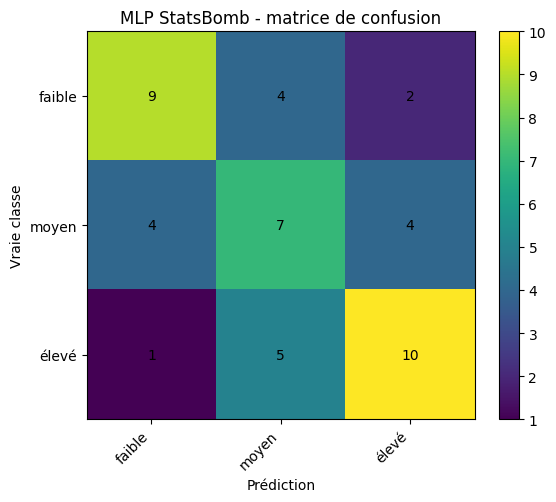

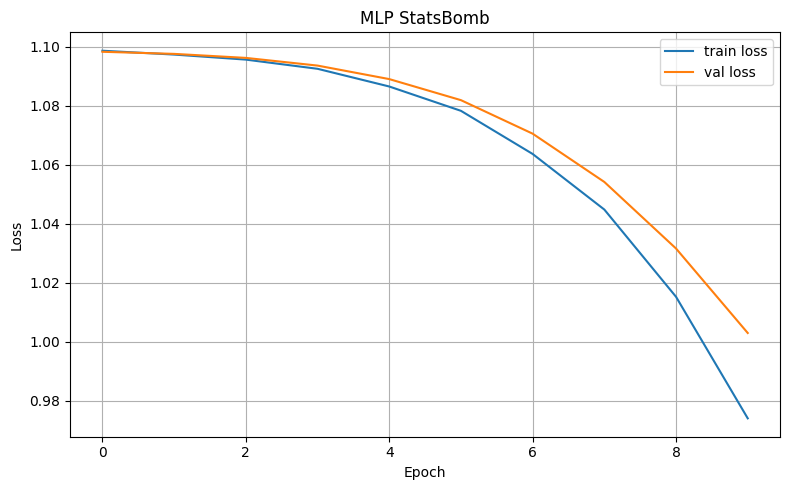

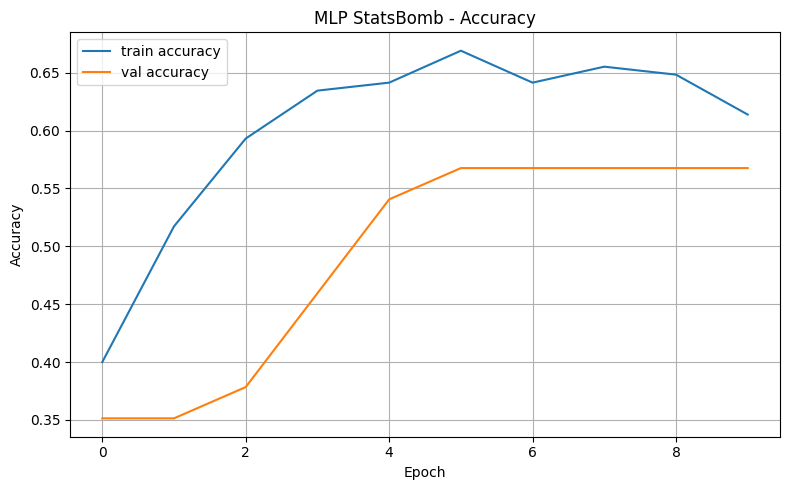

In [ ]:
# ============================================================
# 1. Sauvegarde et rechargement du meilleur MLP
# ============================================================

best_init = mlp_results_df.iloc[0]["initialization"]
print("Meilleure initialisation :", best_init)

best_mlp = MLPCustom(n_features, 64, n_classes_tab)
best_mlp = initialize_model(best_mlp, best_init)
history, best_state = train_classifier(best_mlp, train_loader_tab, val_loader_tab, epochs=10, lr=1e-3, device=DEVICE)
best_mlp.load_state_dict(best_state)

ckpt_path = CHECKPOINT_DIR / "best_mlp_statsbomb.pt"
save_checkpoint(best_mlp, ckpt_path)

reloaded_mlp = MLPCustom(n_features, 64, n_classes_tab).to(DEVICE)
reloaded_mlp = load_checkpoint(reloaded_mlp, ckpt_path, device=DEVICE)

_, metrics_reloaded, y_true_mlp, y_pred_mlp = evaluate_classifier(reloaded_mlp, test_loader_tab, device=DEVICE, return_preds=True)
print("Métriques du modèle rechargé :", metrics_reloaded)
plot_confusion_matrix_simple(y_true_mlp, y_pred_mlp, ["faible", "moyen", "élevé"], "MLP StatsBomb - matrice de confusion", "mlp_confusion_matrix.png")
plot_training_curves(history, "MLP StatsBomb", "mlp_training_curves.png")

## Analyse critique — Partie I

Après exécution du notebook de la Partie I, les résultats obtenus montrent que le MLP constitue une solution pertinente pour traiter des données tabulaires issues de StatsBomb, mais que ses performances restent fortement dépendantes de la qualité des variables construites et de la taille du dataset.

### Qualité des données

Le dataset utilisé contient **228 tirs** extraits de matchs StatsBomb. Après préparation, la cible a été divisée en trois classes : **faible**, **moyen** et **élevé**. Les classes sont équilibrées, avec environ **76 tirs par classe**, ce qui est un point positif car cela évite que le modèle favorise une classe dominante pendant l’apprentissage.

Le modèle utilise **29 variables d’entrée** après encodage et normalisation. Ces variables décrivent plusieurs aspects du tir, comme la position, la distance, l’angle, la minute, la pression défensive, le type de tir, la partie du corps utilisée et certaines informations contextuelles.

Cependant, le nombre total d’exemples reste limité pour entraîner un réseau de neurones de manière robuste. Avec seulement 228 tirs, le modèle peut apprendre certaines tendances générales, mais il risque de ne pas capturer toute la diversité des situations réelles de match. De plus, la cible est dérivée du **xG**, ce qui signifie que le modèle apprend une catégorisation construite à partir d’un indicateur déjà calculé. Il ne prédit donc pas directement un événement réel comme **but / non-but**, mais une classe de danger construite à partir du xG.

### Pertinence du MLP

Le MLP est adapté à cette partie car les données sont représentées sous forme de **vecteurs tabulaires normalisés**. Chaque tir est décrit par un ensemble fixe de caractéristiques numériques ou encodées. Dans ce contexte, un perceptron multicouche peut apprendre des relations non linéaires entre les variables et la classe cible.

Les résultats montrent que le modèle apprend effectivement à partir des données, mais les performances restent modestes. Le MLP `nn.Sequential` obtient de meilleurs résultats que le MLP personnalisé dans cette exécution, avec environ **69,57 % d’accuracy** et **69,80 % de F1-score**. Le meilleur MLP personnalisé rechargé obtient environ **56,52 % d’accuracy** et **56,71 % de F1-score**.

Cette différence montre que les performances peuvent varier selon l’architecture exacte, l’initialisation, le dropout, le nombre d’époques et la dynamique d’entraînement. Le MLP reste donc pertinent pour une classification tabulaire simple, mais il ne modélise pas explicitement certaines interactions statistiques complexes comme peuvent le faire des modèles spécialisés pour données tabulaires, par exemple Random Forest, XGBoost, TabNet ou FT-Transformer.

### Initialisation des poids

Trois stratégies d’initialisation ont été comparées : **gaussienne**, **constante** et **Xavier**.

Dans cette exécution, l’initialisation gaussienne obtient les meilleurs résultats parmi les trois stratégies testées, avec un F1-score d’environ **58,06 %**. L’initialisation Xavier obtient un F1-score d’environ **49,74 %**, tandis que l’initialisation constante obtient le résultat le plus faible avec environ **45,49 %** de F1-score.

L’initialisation constante est la moins intéressante d’un point de vue théorique et expérimental. Comme tous les neurones commencent avec des poids identiques, ils peuvent recevoir des gradients similaires et apprendre des représentations redondantes. Ce phénomène est appelé **problème de symétrie**. Même si le modèle parvient à apprendre légèrement, cette stratégie limite fortement la capacité du réseau à diversifier ses neurones.

L’initialisation Xavier est généralement recommandée pour stabiliser la variance des activations entre les couches. Cependant, dans cette expérience précise, elle ne donne pas le meilleur résultat. Cela peut s’expliquer par la petite taille du dataset, le faible nombre d’époques, le découpage train/validation/test ou la sensibilité du modèle aux hyperparamètres.

### Interprétation des courbes et de la matrice de confusion

Les courbes d’entraînement montrent une diminution progressive de la perte. Pour le MLP `nn.Sequential`, la perte d’entraînement passe d’environ **1,26** à **0,80**, tandis que la perte de validation passe d’environ **1,03** à **0,88**. Cette évolution indique que le modèle apprend effectivement à partir des données.

La perte de validation reste proche de la perte d’entraînement, ce qui suggère qu’il n’y a pas de surapprentissage très marqué. Cependant, les performances restent limitées, ce qui montre que le modèle manque probablement d’informations suffisantes pour séparer clairement les trois classes.

La matrice de confusion du meilleur MLP personnalisé montre **26 bonnes prédictions sur 46 exemples de test**. Le modèle reconnaît une partie des tirs des classes **faible**, **moyen** et **élevé**, mais les confusions restent importantes. La classe **moyen** est particulièrement difficile à séparer, car elle se situe naturellement entre les deux extrêmes. Certains tirs moyens peuvent ressembler à des tirs faibles ou élevés selon leur distance, leur angle ou leur contexte.

### Limites de l’expérience

La principale limite de cette partie est la taille du dataset. Les **228 tirs** utilisés ne suffisent pas forcément pour généraliser à d’autres compétitions, équipes ou styles de jeu. La compétition choisie influence fortement les situations observées : qualité des joueurs, niveau défensif, types d’actions et fréquence des tirs. Si le nombre de matchs est petit, le modèle risque d’apprendre des particularités propres à cet échantillon au lieu d’apprendre des règles générales.

Une autre limite concerne la cible. Comme les classes sont dérivées du **xG**, le modèle apprend à reproduire une information déjà calculée à partir de certaines caractéristiques du tir. Cette démarche reste utile pédagogiquement pour une tâche de classification tabulaire, mais elle limite l’interprétation métier du modèle.

Enfin, les variables utilisées ne décrivent pas totalement la situation de jeu. Des informations comme la position exacte des défenseurs, la vitesse de l’action, la pression réelle autour du tireur, le type de passe précédente, l’organisation défensive ou la position du gardien pourraient améliorer la qualité prédictive du modèle.

### Conclusion critique

En conclusion, un MLP bien paramétré constitue une solution pertinente pour une classification tabulaire simple sur des données de tirs footballistiques. Il permet d’apprendre des relations non linéaires entre les caractéristiques du tir et le niveau de danger associé.

Cependant, ses performances dépendent fortement de l’ingénierie des variables, de la qualité du dataset, du choix de l’initialisation, de la normalisation et du volume de données disponible. Le MLP est donc une bonne base pour les données tabulaires, mais il devrait être comparé à des modèles tabulaires spécialisés et entraîné sur un dataset plus large pour obtenir une meilleure généralisation.

## Question de synthèse — Partie I

**Réponse attendue dans le rapport :**

Un MLP est pertinent pour ce dataset car chaque tir est représenté par un vecteur de caractéristiques numériques et catégorielles encodées. La normalisation facilite l'entraînement, tandis que l'utilisation de couches entièrement connectées permet de combiner les variables comme la distance au but, l'angle, la minute ou le type de tir. Les expériences d'initialisation montrent l'influence du choix des poids de départ sur la stabilité et les performances. Cependant, le MLP ne connaît pas directement la structure du terrain ni le contexte collectif complet de l'action ; ses limites viennent donc de la représentation tabulaire et de la quantité de données disponible.
